# Script for neural network

In [1]:
#%pip install pandas --user --quiet
#%pip install numpy  --user --quiet
#%pip install scikit-learn --user --quiet
#%pip install matplotlib --user --quiet
#%pip install torch --user 
#%pip install seaborn
#%pip install tensorflow --user
#%pip install xgboost --user --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # antes de import tensorflow
import tensorflow as tf
from tensorflow import keras

We remove the 'r_status' column from the dataset before proceeding with further analysis. Because it contains information about the reservation status, which could lead to data leakage in predictive modeling tasks.

In [3]:
df = pd.read_csv('../hotel_sample_5000.csv')
df = df.drop(columns=['r_status'])
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4866 entries, 0 to 4865
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   hotel                4866 non-null   object 
 1   canceled             4866 non-null   int64  
 2   lead_time            4866 non-null   int64  
 3   year                 4866 non-null   int64  
 4   month                4866 non-null   object 
 5   week                 4866 non-null   int64  
 6   day                  4866 non-null   int64  
 7   weekend_nights       4866 non-null   int64  
 8   week_nights          4866 non-null   int64  
 9   adults               4866 non-null   int64  
 10  children             4866 non-null   int64  
 11  babies               4866 non-null   int64  
 12  meal                 4866 non-null   object 
 13  country              4866 non-null   object 
 14  market_seg           4866 non-null   object 
 15  channel              4866 non-null   o

First we will do a one-hot encoding of the categorical variables in our dataset.

In [4]:
cat_variables = ['hotel', 'month', 'meal', 'country', 'market_seg', 'channel','rroom_type','assroom_type', 'deposit_type', 'agent', 'customer_type', 'rs_date']
df = pd.get_dummies(df, columns=cat_variables, drop_first=False)

In [5]:
from sklearn.model_selection import train_test_split

y_cat = df['canceled']
X_cat = df.drop(columns='canceled')

y_num = df['adr']
X_num = df.drop(columns='adr')

# Split dataset for canceled
X_cat_train, X_aux, y_cat_train, y_aux = train_test_split(
    X_cat, y_cat, test_size=0.3, random_state=42, stratify=y_cat
)

X_cat_val, X_cat_test, y_cat_val, y_cat_test = train_test_split(
    X_aux, y_aux, test_size=0.5, random_state=42, stratify=y_aux
)

# Split dataset for adr
X_num_train, X_aux, y_num_train, y_aux = train_test_split(
    X_num, y_num, test_size=0.3, random_state=42, shuffle=True
)

X_num_val, X_num_test, y_num_val, y_num_test = train_test_split(
    X_aux, y_aux, test_size=0.5, random_state=42, shuffle=True
)

Now we are going to normalize the numerical variables in our dataset using Min-Max scaling. We do it after the splitting to avoid data leakage.

In [6]:
from sklearn.preprocessing import MinMaxScaler

def get_continuous_cols(df):
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    binary_cols = [c for c in num_cols if set(df[c].dropna().unique()).issubset({0,1})]
    return [c for c in num_cols if c not in binary_cols]


# For clasification (canceled)
cont_cat_cols = get_continuous_cols(X_cat_train)
scaler_cat = MinMaxScaler()
scaler_cat.fit(X_cat_train.loc[:, cont_cat_cols])

X_cat_train.loc[:, cont_cat_cols] = scaler_cat.transform(X_cat_train.loc[:, cont_cat_cols])
X_cat_val.loc[:, cont_cat_cols]   = scaler_cat.transform(X_cat_val.loc[:, cont_cat_cols])
X_cat_test.loc[:, cont_cat_cols]  = scaler_cat.transform(X_cat_test.loc[:, cont_cat_cols])

# For regresion (adr)
cont_num_cols = get_continuous_cols(X_num_train)
scaler_num = MinMaxScaler()
scaler_num.fit(X_num_train.loc[:, cont_num_cols])

X_num_train.loc[:, cont_num_cols] = scaler_num.transform(X_num_train.loc[:, cont_num_cols])
X_num_val.loc[:, cont_num_cols]   = scaler_num.transform(X_num_val.loc[:, cont_num_cols])
X_num_test.loc[:, cont_num_cols]  = scaler_num.transform(X_num_test.loc[:, cont_num_cols])

/var/folders/l5/_6v933rj0k9gdbm_k3y3w3ph0000gn/T/ipykernel_24457/180399739.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.01277955 0.03833866 0.30990415 ... 0.36900958 0.00798722 0.22044728]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_cat_train.loc[:, cont_cat_cols] = scaler_cat.transform(X_cat_train.loc[:, cont_cat_cols])
/var/folders/l5/_6v933rj0k9gdbm_k3y3w3ph0000gn/T/ipykernel_24457/180399739.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.5 0.5 1.  ... 0.  0.5 0.5]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_cat_train.loc[:, cont_cat_cols] = scaler_cat.transform(X_cat_train.loc[:, cont_cat_cols])
/var/folders/l5/_6v933rj0k9gdbm_k3y3w3ph0000gn/T/ipykernel_24457/180399739.py:14: FutureWarning: Setting an item of incompatible dtype

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# N_FEATURES es el número de columnas después del preprocesamiento
N_FEATURES_CAT = X_cat_train.shape[1] 
N_FEATURES_NUM = X_num_train.shape[1] 

# --- MODELO 1: CLASIFICACIÓN (Canceled) ---
model_classification = Sequential([
    Input(shape=(N_FEATURES_CAT,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    # Capa de Salida: 1 neurona, activación Sigmoid
    Dense(1, activation='sigmoid') 
])

model_classification.compile(
    optimizer='adam',
    loss='binary_crossentropy', # Pérdida estándar para clasificación binaria
    metrics=['accuracy', 'AUC'] 
)

# --- MODELO 2: REGRESIÓN (ADR) ---
model_regression = Sequential([
    Input(shape=(N_FEATURES_NUM,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    # Capa de Salida: 1 neurona, activación lineal (sin activación)
    Dense(1, activation='linear') 
])

model_regression.compile(
    optimizer='adam',
    loss='mean_squared_error', # Pérdida estándar para regresión
    metrics=['mae'] 
)

Remove the comments if you want to train the neural network model again.

In [ ]:
# import seaborn as sns
# from tensorflow.keras.callbacks import EarlyStopping
# import itertools
# import json

# # --- CONFIGURATIONS TO TEST ---
# # Different architectures (number of neurons per layer)
# architectures = [
#     [64, 32],
#     [128, 64],
#     [128, 64, 32],
#     [256, 128],
#     [256, 128, 64],
# ]

# # Different activation functions
# activations = ['relu', 'tanh', 'elu']

# # Early stopping to avoid overfitting
# early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# # --- CLASSIFICATION EXPERIMENTS ---
# print("EXPERIMENTING WITH CLASSIFICATION (Canceled)")

# best_config_cat = {'val_auc': 0, 'architecture': None, 'activation': None}
# results_cat = []

# for arch, act in itertools.product(architectures, activations):
#     print(f"\nTesting architecture {arch} with activation '{act}'...")
    
#     # Build model
#     model = Sequential([Input(shape=(N_FEATURES_CAT,))])
#     for neurons in arch:
#         model.add(Dense(neurons, activation=act))
#     model.add(Dense(1, activation='sigmoid'))
    
#     model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'AUC'])
    
#     # Train
#     history = model.fit(
#         X_cat_train, y_cat_train,
#         validation_data=(X_cat_val, y_cat_val),
#         epochs=100,
#         batch_size=32,
#         verbose=0,
#         callbacks=[early_stop]
#     )
    
#     # Evaluate
#     val_loss, val_acc, val_auc = model.evaluate(X_cat_val, y_cat_val, verbose=0)
#     test_loss, test_acc, test_auc = model.evaluate(X_cat_test, y_cat_test, verbose=0)
    
#     print(f"  Val AUC: {val_auc:.4f} | Test AUC: {test_auc:.4f}")
    
#     results_cat.append({
#         'architecture': arch,
#         'activation': act,
#         'val_loss': val_loss,
#         'val_acc': val_acc,
#         'val_auc': val_auc,
#         'test_loss': test_loss,
#         'test_acc': test_acc,
#         'test_auc': test_auc
#     })
    
#     # Update best configuration
#     if val_auc > best_config_cat['val_auc']:
#         best_config_cat = {
#             'val_auc': val_auc,
#             'architecture': arch,
#             'activation': act,
#             'model': model,
#             'history': history
#         }

# print()
# print("BEST CLASSIFICATION CONFIGURATION:")
# print(f"  Architecture: {best_config_cat['architecture']}")
# print(f"  Activation: {best_config_cat['activation']}")
# print(f"  Val AUC: {best_config_cat['val_auc']:.4f}")

# # --- REGRESSION EXPERIMENTS ---
# print("EXPERIMENTING WITH REGRESSION (ADR)")

# best_config_num = {'val_mae': float('inf'), 'architecture': None, 'activation': None}
# results_num = []

# for arch, act in itertools.product(architectures, activations):
#     print(f"\nTesting architecture {arch} with activation '{act}'...")
    
#     # Build model
#     model = Sequential([Input(shape=(N_FEATURES_NUM,))])
#     for neurons in arch:
#         model.add(Dense(neurons, activation=act))
#     model.add(Dense(1, activation='linear'))
    
#     model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
    
#     # Train
#     history = model.fit(
#         X_num_train, y_num_train,
#         validation_data=(X_num_val, y_num_val),
#         epochs=100,
#         batch_size=32,
#         verbose=0,
#         callbacks=[early_stop]
#     )
    
#     # Evaluate
#     val_loss, val_mae = model.evaluate(X_num_val, y_num_val, verbose=0)
#     test_loss, test_mae = model.evaluate(X_num_test, y_num_test, verbose=0)
    
#     print(f"  Val MAE: {val_mae:.4f} | Test MAE: {test_mae:.4f}")
    
#     results_num.append({
#         'architecture': arch,
#         'activation': act,
#         'val_loss': val_loss,
#         'val_mae': val_mae,
#         'test_loss': test_loss,
#         'test_mae': test_mae
#     })
    
#     # Update best configuration (lower MAE is better)
#     if val_mae < best_config_num['val_mae']:
#         best_config_num = {
#             'val_mae': val_mae,
#             'architecture': arch,
#             'activation': act,
#             'model': model,
#             'history': history
#         }

# print()
# print("BEST REGRESSION CONFIGURATION:")
# print(f"  Architecture: {best_config_num['architecture']}")
# print(f"  Activation: {best_config_num['activation']}")
# print(f"  Val MAE: {best_config_num['val_mae']:.4f}")

# # --- SAVE RESULTS TO JSON ---
# with open('experiment_results_classification.json', 'w') as f:
#     json.dump(results_cat, f, indent=2)

# with open('experiment_results_regression.json', 'w') as f:
#     json.dump(results_num, f, indent=2)

# print("\n✓ Results saved to 'experiment_results_*.json'")

# # --- SAVE BEST MODELS ---
# best_config_cat['model'].save('best_model_classification.keras')
# best_config_num['model'].save('best_model_regression.keras')

# print("✓ Best models saved to 'best_model_*.keras'")

# # --- VISUALIZE COMPARISON ---
# df_results_cat = pd.DataFrame(results_cat)
# df_results_num = pd.DataFrame(results_num)

# fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# # Classification
# df_pivot_cat = df_results_cat.pivot_table(
#     values='val_auc', 
#     index='activation', 
#     columns=df_results_cat['architecture'].astype(str)
# )
# sns.heatmap(df_pivot_cat, annot=True, fmt='.3f', cmap='RdYlGn', ax=axes[0], cbar_kws={'label': 'Val AUC'})
# axes[0].set_title('Classification - Val AUC by configuration')
# axes[0].set_xlabel('Architecture')
# axes[0].set_ylabel('Activation')

# # Regression
# df_pivot_num = df_results_num.pivot_table(
#     values='val_mae', 
#     index='activation', 
#     columns=df_results_num['architecture'].astype(str)
# )
# sns.heatmap(df_pivot_num, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=axes[1], cbar_kws={'label': 'Val MAE'})
# axes[1].set_title('Regression - Val MAE by configuration')
# axes[1].set_xlabel('Architecture')
# axes[1].set_ylabel('Activation')

# plt.tight_layout()
# plt.show()

Clasification model evaluation (Canceled)
Loss: 0.3814
Accuracy: 0.8205
AUC: 0.9048

Regression model evaluation (ADR)
MSE: 1506.0046
MAE: 27.1658


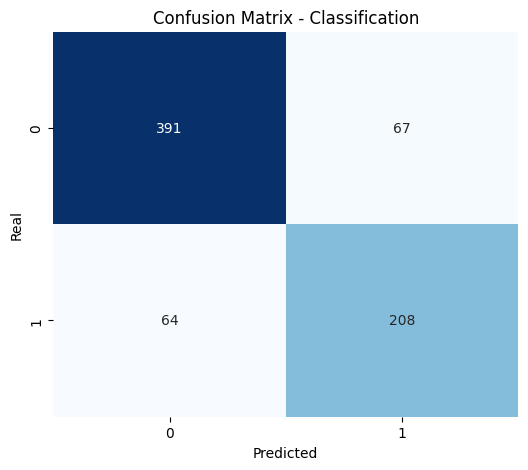


Clasification Report:
              precision    recall  f1-score   support

No Cancelado       0.86      0.85      0.86       458
   Cancelado       0.76      0.76      0.76       272

    accuracy                           0.82       730
   macro avg       0.81      0.81      0.81       730
weighted avg       0.82      0.82      0.82       730



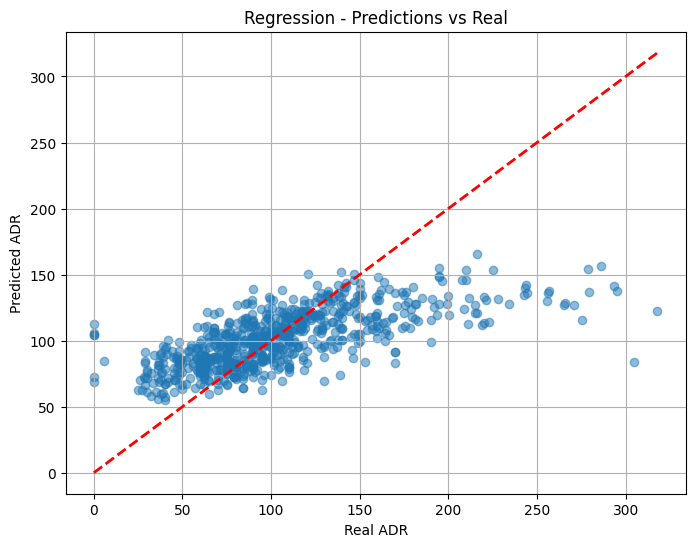

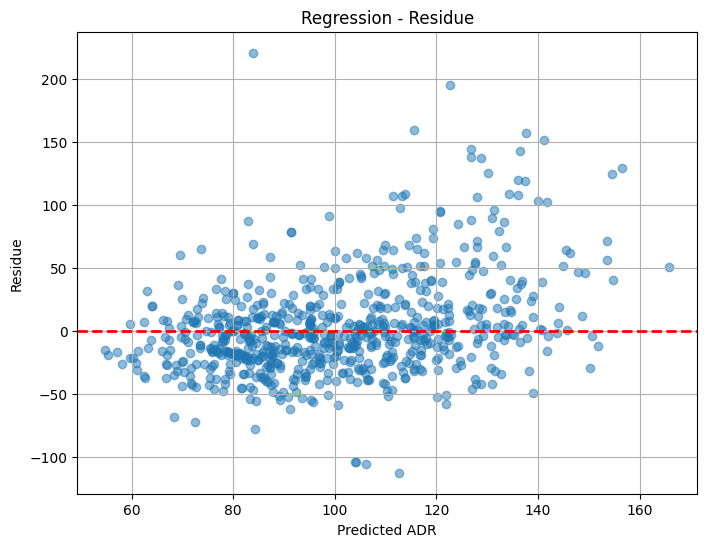


BEST CLASSIFICATION MODEL CONFIGURATION:
  Architecture: [128, 64, 32]
  Activation: relu
  Val AUC: 0.9182
  Test AUC: 0.9048

BEST REGRESSION MODEL CONFIGURATION:
  Architecture: [256, 128, 64]
  Activation: relu
  Val MAE: 27.2901
  Test MAE: 27.1658


In [17]:
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import json

# Load models
model_classification = load_model('../models/best_model_classification.keras')
model_regression = load_model('../models/best_model_regression.keras')

print("Clasification model evaluation (Canceled)")
test_loss_cat, test_acc_cat, test_auc_cat = model_classification.evaluate(X_cat_test, y_cat_test, verbose=0)
print(f"Loss: {test_loss_cat:.4f}")
print(f"Accuracy: {test_acc_cat:.4f}")
print(f"AUC: {test_auc_cat:.4f}")

print()
print("Regression model evaluation (ADR)")
test_loss_num, test_mae_num = model_regression.evaluate(X_num_test, y_num_test, verbose=0)
print(f"MSE: {test_loss_num:.4f}")
print(f"MAE: {test_mae_num:.4f}")

# --- CONFUSION MATRIX (Classification) ---
y_pred_proba = model_classification.predict(X_cat_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

cm = confusion_matrix(y_cat_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Classification')
plt.xlabel('Predicted')
plt.ylabel('Real')
plt.show()

print("\nClasification Report:")
print(classification_report(y_cat_test, y_pred, target_names=['No Cancelado', 'Cancelado']))

y_pred_reg = model_regression.predict(X_num_test, verbose=0).flatten()

plt.figure(figsize=(8, 6))
plt.scatter(y_num_test, y_pred_reg, alpha=0.5)
plt.plot([y_num_test.min(), y_num_test.max()], [y_num_test.min(), y_num_test.max()], 'r--', lw=2)
plt.xlabel('Real ADR')
plt.ylabel('Predicted ADR')
plt.title('Regression - Predictions vs Real')
plt.grid(True)
plt.show()

# --- RESIDUOS (Regresión) ---
residuos = y_num_test - y_pred_reg
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_reg, residuos, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted ADR')
plt.ylabel('Residue')
plt.title('Regression - Residue')
plt.grid(True)
plt.show()

# --- LOAD AND SHOW CONFIGURATIONS ---
with open('../experiment_results_classification.json', 'r') as f:
    results_cat = json.load(f)

with open('../experiment_results_regression.json', 'r') as f:
    results_num = json.load(f)

# Find and show the best configurations
best_cat = max(results_cat, key=lambda x: x['val_auc'])
best_num = min(results_num, key=lambda x: x['val_mae'])

print()
print("BEST CLASSIFICATION MODEL CONFIGURATION:")
print(f"  Architecture: {best_cat['architecture']}")
print(f"  Activation: {best_cat['activation']}")
print(f"  Val AUC: {best_cat['val_auc']:.4f}")
print(f"  Test AUC: {best_cat['test_auc']:.4f}")

print()
print("BEST REGRESSION MODEL CONFIGURATION:")
print(f"  Architecture: {best_num['architecture']}")
print(f"  Activation: {best_num['activation']}")
print(f"  Val MAE: {best_num['val_mae']:.4f}")
print(f"  Test MAE: {best_num['test_mae']:.4f}")


Outliers detectados: 135 (2.8%)
Rango sin outliers: [-16.80, 216.00]


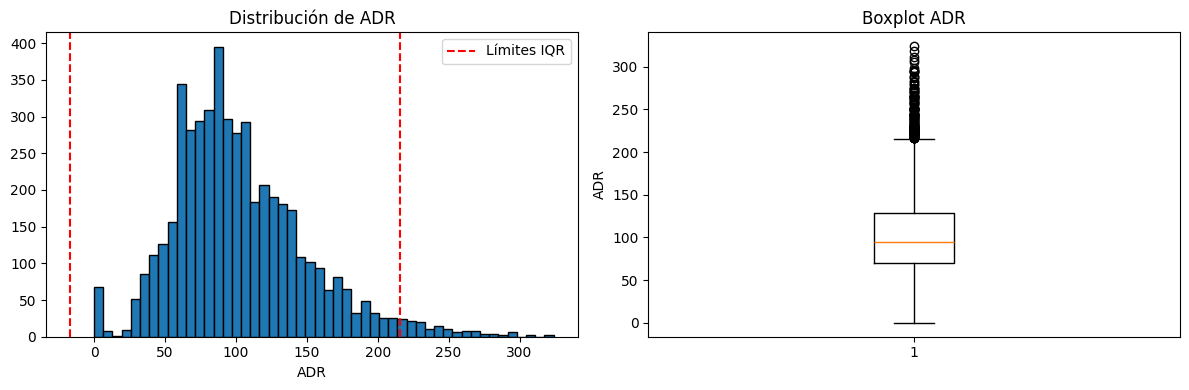

In [ ]:

Q1 = y_num.quantile(0.25)
Q3 = y_num.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = y_num[(y_num < lower_bound) | (y_num > upper_bound)]
print(f"Outliers detectados: {len(outliers)} ({len(outliers)/len(y_num)*100:.1f}%)")
print(f"Rango sin outliers: [{lower_bound:.2f}, {upper_bound:.2f}]")

# Visualizar distribución
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y_num, bins=50, edgecolor='black')
axes[0].set_title('Distribución de ADR')
axes[0].set_xlabel('ADR')
axes[0].axvline(lower_bound, color='r', linestyle='--', label='Límites IQR')
axes[0].axvline(upper_bound, color='r', linestyle='--')
axes[0].legend()

axes[1].boxplot(y_num)
axes[1].set_title('Boxplot ADR')
axes[1].set_ylabel('ADR')
plt.tight_layout()
plt.show()


In [ ]:
# Baseline: predecir siempre la media
baseline_mae = np.abs(y_num_test - y_num_test.mean()).mean()
print(f"\nComparación con baseline (predecir media):")
print(f"  Baseline MAE: {baseline_mae:.2f}")
print(f"  Modelo MAE: {test_mae_num:.2f}")
print(f"  Mejora: {((baseline_mae - test_mae_num) / baseline_mae * 100):.1f}%")

# R² score
from sklearn.metrics import r2_score
r2 = r2_score(y_num_test, y_pred_reg)
print(f"\nR² Score: {r2:.4f}")
print(f"  (Explained variability: {r2*100:.1f}%)")


Comparación con baseline (predecir media):
  Baseline MAE: 37.86
  Modelo MAE: 27.17
  Mejora: 28.2%

R² Score: 0.4062
  (Varianza explicada: 40.6%)



Results XGBoost:
  MAE: 13.59
  MSE: 509.62
  RMSE: 22.57
  R²: 0.7991

Comparison with neural network
  Neural Network - MAE: 27.17 | R²: 0.4062
  XGBoost        - MAE: 13.59 | R²: 0.7991
  XGBoost Improvement: 50.0% in MAE


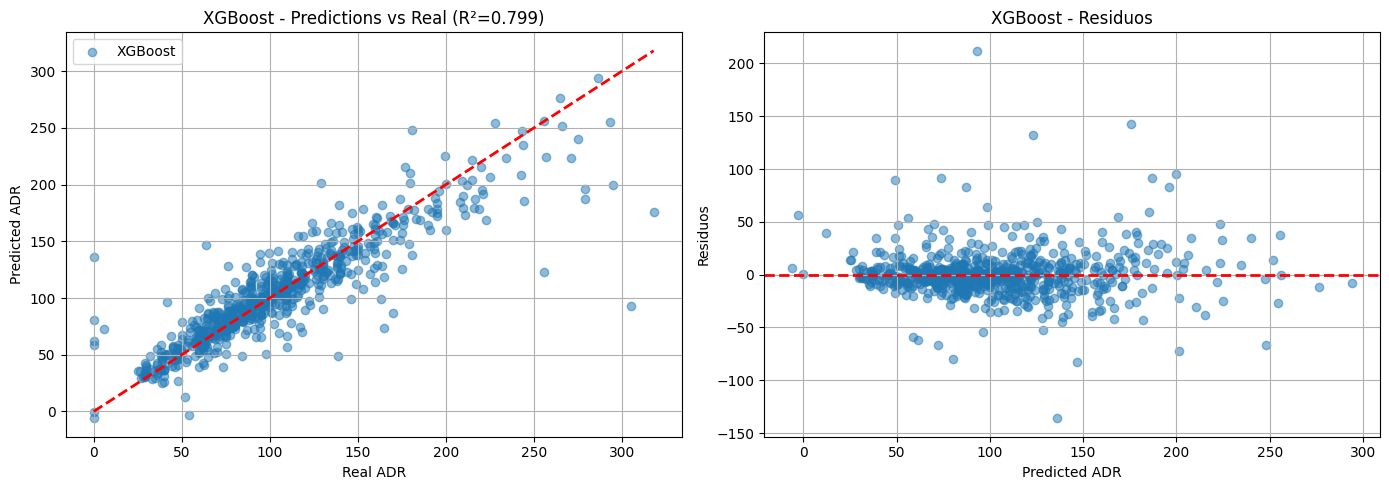

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

xgb_model = xgb.XGBRegressor(
    n_estimators=2000,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=3011,
    n_jobs=-1
)

xgb_model.fit(
    X_num_train, y_num_train,
    eval_set=[(X_num_val, y_num_val)],
    verbose=False
)

# --- Prediction ---
y_pred_xgb = xgb_model.predict(X_num_test)

# --- Evaluation ---
xgb_mae = mean_absolute_error(y_num_test, y_pred_xgb)
xgb_mse = mean_squared_error(y_num_test, y_pred_xgb)
xgb_r2 = r2_score(y_num_test, y_pred_xgb)

print(f"\nResults XGBoost:")
print(f"  MAE: {xgb_mae:.2f}")
print(f"  MSE: {xgb_mse:.2f}")
print(f"  RMSE: {np.sqrt(xgb_mse):.2f}")
print(f"  R²: {xgb_r2:.4f}")

print(f"\nComparison with neural network")
print(f"  Neural Network - MAE: {test_mae_num:.2f} | R²: {r2:.4f}")
print(f"  XGBoost        - MAE: {xgb_mae:.2f} | R²: {xgb_r2:.4f}")
print(f"  XGBoost Improvement: {((test_mae_num - xgb_mae) / test_mae_num * 100):.1f}% in MAE")

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predictions vs Real
axes[0].scatter(y_num_test, y_pred_xgb, alpha=0.5, label='XGBoost')
axes[0].plot([y_num_test.min(), y_num_test.max()], 
             [y_num_test.min(), y_num_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Real ADR')
axes[0].set_ylabel('Predicted ADR')
axes[0].set_title(f'XGBoost - Predictions vs Real (R²={xgb_r2:.3f})')
axes[0].grid(True)
axes[0].legend()

# Residuals
residuos_xgb = y_num_test - y_pred_xgb
axes[1].scatter(y_pred_xgb, residuos_xgb, alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted ADR')
axes[1].set_ylabel('Residuos')
axes[1].set_title('XGBoost - Residuos')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# --- IMPORTANCIA DE FEATURES (Top 15) ---
# feature_importance = pd.DataFrame({
#     'feature': X_num_train.columns,
#     'importance': xgb_model.feature_importances_
# }).sort_values('importance', ascending=False).head(15)

# plt.figure(figsize=(10, 6))
# plt.barh(feature_importance['feature'], feature_importance['importance'])
# plt.xlabel('Importancia')
# plt.title('Top 15 Features más importantes (XGBoost)')
# plt.gca().invert_yaxis()
# plt.tight_layout()
# plt.show()

# print("\nTop 5 features más importantes:")
# print(feature_importance.head().to_string(index=False))